# Analisi Diffusione COVID-19
Analisi dei dati COVID-19 raccolti da *Our World in Data*, con focus su casi per continente, andamento Italia 2022, pazienti ICU e ospedalizzati in Europa.

## Setup
Importazione delle librerie necessarie e caricamento del dataset.

In [47]:
# Importiamo le librerie
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
# Otteniamo il dataset
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
covid = pd.read_csv(url)

## 1. Verificare le dimensioni del dataset e i relativi metadati - EDA
Prima esplorazione del dataset per capire struttura, dimensioni e tipo di dati disponibili.

In [49]:
covid  # 429.435 righe x 67 colonne 
covid.info()  # Utile per capire i metadati. Abbiamo una vista delle colonne con conteggio di valori non-null e datatypes

covid.date.head(50)  # Con alcuni head/tail si può desumere che i dati temporali presentano tutti i giorni dal 2020-01-05 al 2024-08-04
covid.date.tail(50)

print("----------------------")
print("----------------------")
covid.describe() #analisi delle colonne numeriche

print("----------------------")
print("----------------------")
print("Di seguito l'analisi delle colonne categoriche:")
for colonna in covid.columns:
    if covid[colonna].dtype == "object":
        valori_unici = covid[colonna].nunique()
        print(f"{colonna} contiene {valori_unici} valori univoci")
        print("----------------------")


covid.location.value_counts().head(50)  

# Commento ai dati ottenuti fin qui: 
# Location contiene in media 255 valori univoci, ciascun paese compare in media 1.684 volte. 
# Se ne può desumere che i dati probabilmente riportano le stesse variabili ripetute ogni giorno dal 2020-01-05 al 2024-08-04. 
# Il dataset contiene la fotografia di ogni paese giorno dopo giorno della situazione covid.
# Alcuni dati sono valori assoluti di un giorno singolo (es. 'new deaths'), altri sono somme cumulate (es. 'total deaths'), alti ancora sono indici anagrafici del paese (es. 'population', 'life_expectancy', ecc.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

location
High-income countries            3026
European Union (27)              3024
Upper-middle-income countries    3013
Lower-middle-income countries    2983
Low-income countries             2724
East Timor                       2688
Faroe Islands                    2068
Asia                             1684
Malaysia                         1684
Europe                           1684
Lithuania                        1684
World                            1684
India                            1682
Estonia                          1682
Czechia                          1682
Oceania                          1681
New Zealand                      1681
Mexico                           1678
Argentina                        1678
Italy                            1677
Thailand                         1675
Puerto Rico                      1674
Niger                            1674
Qatar                            1674
Nigeria                          1674
Niue                             1674
Nor

## 2. Casi COVID per continente
Numero di casi totali per ogni continente all'ultima data disponibile e percentuale rispetto al totale mondiale.

In [50]:
continenti = ["Africa", "Asia", "Europe", "North America", "Oceania", "South America"]   # i continenti stanno già dentro location
filtro_last = (
    (covid["date"] == "2024-08-01") &              # all'ultima data disponibile del 2024-08-07 sono presenti pochi dati. Si sceglie questa data leggermente antecedente per avere tutti i dati a disposizione.
    (covid["location"].isin(continenti))
)
covid_last = covid[filtro_last]
dati_continenti = covid_last[["location", "date", "total_cases"]]   
totale_casi = dati_continenti["total_cases"].sum()
dati_continenti["perc_casi"] = dati_continenti["total_cases"] / totale_casi * 100
dati_continenti

C:\Users\giovanni.esposito\AppData\Local\Temp\ipykernel_28796\1719394207.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dati_continenti["perc_casi"] = dati_continenti["total_cases"] / totale_casi * 100


,location,date,total_cases,perc_casi
3344,Africa,2024-08-01,13145344.0,1.694381
21762,Asia,2024-08-01,301494584.0,38.861428
120239,Europe,2024-08-01,252877821.0,32.594925
278855,North America,2024-08-01,124492212.0,16.046541
289288,Oceania,2024-08-01,15001543.0,1.933638
359234,South America,2024-08-01,68808110.0,8.869086


## 3. Italia 2022 — andamento casi
Selezione dei dati italiani nel 2022, filtrando i giorni senza misurazione. Analisi dell'evoluzione dei casi totali e nuovi casi.

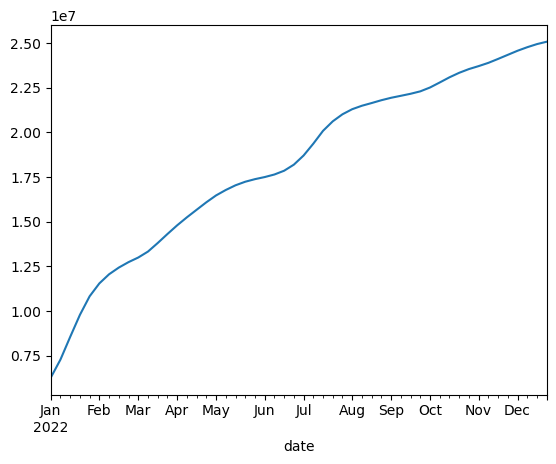

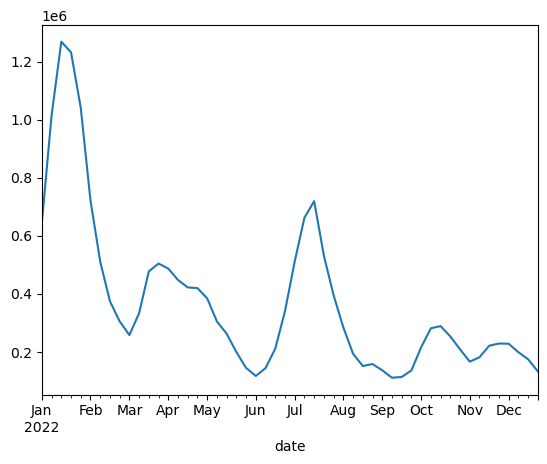

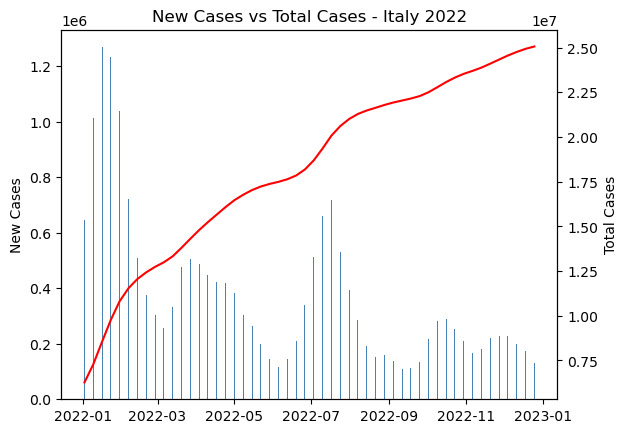

In [51]:
# 3. Dati italia 2022
covid["date"] = pd.to_datetime(covid["date"], yearfirst=True)
covid["year"] = covid.date.dt.year
filtroita22 =  (
    (covid["year"] == 2022) &              
    (covid["location"] == "Italy") &
    (covid["new_cases"] != 0)
)

covid_ita22 = covid[filtroita22]

covid_ita22_tcasi = covid_ita22[["date", "total_cases"]]
covid_ita22_tcasi = covid_ita22_tcasi.set_index("date")
plt.figure()
covid_ita22_tcasi.total_cases.plot() # il grafico che risulta mostra l'andamento dei casi totali in italia nel corso del 2022. La notazione '1e6' indica '× 1.000.000'. I casi sono cresciuti oscillato da circa 700.000 a circa 2.500.000.

covid_ita22_ncasi = covid_ita22[["date", "new_cases"]]
covid_ita22_ncasi = covid_ita22_ncasi.set_index("date")
plt.figure()
covid_ita22_ncasi.new_cases.plot()    # il grafico che risulta mostra l'andamento dei nuovi casi in italia nel corso del 2022. La notazione '1e6' indica '× 1.000.000'. I casi hanno quindi oscillato tra circa 200.000 e circa 1.200.000.

# idea aggiuntiva: fare un grafico combinato istogramma per new_cases e linea per total_cases. Ho chiesto ad AI come si può fare:
fig, ax1 = plt.subplots()

# istogramma new cases
ax1.bar(covid_ita22_ncasi.index, covid_ita22_ncasi["new_cases"], color="steelblue", label="New Cases")
ax1.set_ylabel("New Cases")

# linea total cases su asse secondario
ax2 = ax1.twinx()
ax2.plot(covid_ita22_tcasi.index, covid_ita22_tcasi["total_cases"], color="red", label="Total Cases")
ax2.set_ylabel("Total Cases")

plt.title("New Cases vs Total Cases - Italy 2022")
plt.show()


## 4. Pazienti in terapia intensiva — Italia, Germania, Francia
Confronto tramite boxplot dei pazienti ICU nei tre paesi da maggio 2022 ad aprile 2023.

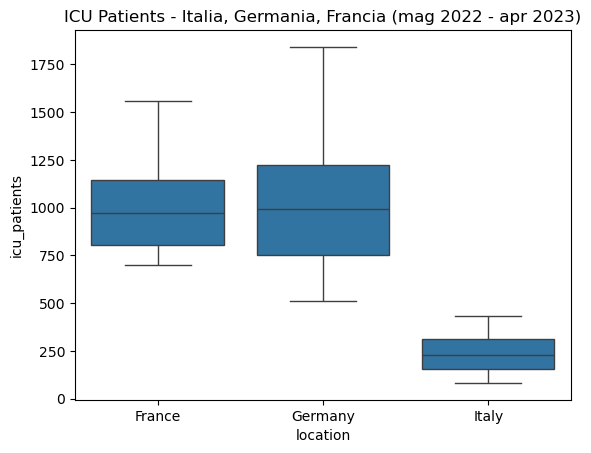

In [52]:
paesi_4 = ["Italy", "Germany", "France"]
filtro_4 = (
    (covid["location"].isin(paesi_4)) &
    (covid["date"] >= "2022-05-01") &
    (covid["date"] <= "2023-04-30") &
    (covid["icu_patients"].notna())
)
covid_4 = covid[filtro_4]
plt.figure()
sns.boxplot(data=covid_4, x="location", y="icu_patients")
plt.title("ICU Patients - Italia, Germania, Francia (mag 2022 - apr 2023)")
plt.show()
# Il boxplot mostra per ogni paese la distribuzione dei pazienti ICU nel periodo considerato.
# Il box centrale contiene il 50% dei valori (tra Q1 e Q3), la linea centrale è la mediana, i baffi indicano il range normale dei dati escludendo gli outlier.
# Francia e Germania hanno mediane simili ( circ 1000 pazienti) ma Germania più variabile — il box più alto indica maggiore oscillazione nel numero di ricoveri.
# Italia si distingue nettamente con mediana di circa 200 pazienti e box molto compresso.




## 5. Pazienti ospedalizzati — Italia, Germania, Francia, Spagna
Analisi della somma dei pazienti ospedalizzati nel 2021 e verifica dei valori nulli.

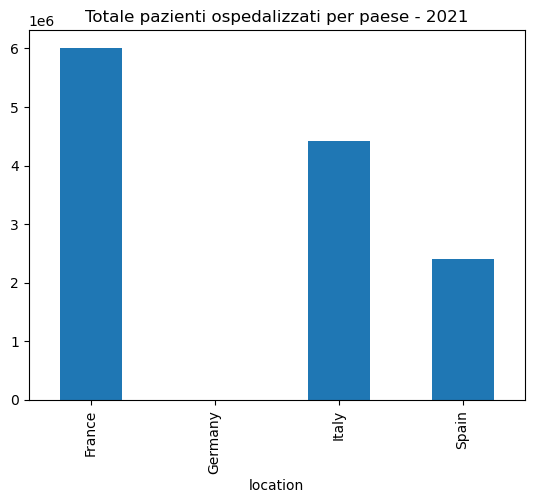

Valori NON nulli hosp_patients per paese: 
location
France     365
Germany      0
Italy      365
Spain      365
Name: hosp_patients, dtype: int64


In [53]:
paesi_5 = ["Italy", "Germany", "France", "Spain"]
filtro_5 = (
    (covid["location"].isin(paesi_5)) &
    (covid["year"] == 2021)
)
covid_5 = covid[filtro_5]
somma_osp = covid_5.groupby("location")["hosp_patients"].sum()
plt.figure()
somma_osp.plot(kind="bar")
plt.title("Totale pazienti ospedalizzati per paese - 2021")
plt.show()

print("Valori NON nulli hosp_patients per paese: ")
print(covid_5.groupby("location")["hosp_patients"].count())
# La Germania nel 2021 non ha nessun dato per hosp_patients. Si tratta di una lacuna sistematica, che non si può gestire tramite metodi di sostituzione (interpolazione o fillna).
# Per Francia, Italia e Spagna i dati sono completi (365 valori) e eventuali null si possono gestire con il metodo dell' interpolazione.